# SFT Results


In [24]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')


In [25]:
# ============================================
# Configuration (4 settings; Llama-3.2-1B; fixed LRs)
# ============================================
repo_root = Path(os.environ.get('DRPT_REPO_ROOT', Path.cwd())).resolve()
if 'DRPT_REPO_ROOT' not in os.environ:
    repo_root = next((p for p in (repo_root, *repo_root.parents) if (p / 'SFT').is_dir()), repo_root)
out_dir = Path(os.environ.get('DRPT_RUNS_DIR', repo_root / 'SFT' / 'runs'))
config_base = './train/configs'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

default_model = 'meta-llama/Llama-3.2-1B'

def _model_short(hf_name):
    return hf_name.split('/')[-1]

# 4 active settings. `config` is the dir under train/configs/, `prefix` is the
# run-dir prefix (which uses {train}_{task} — different from `config` only for
# triviaqa_nq, whose run-dir prefix is triviaqa_nq_open).
#
# Optional per-setting visual clipping for the trajectory plots:
#   y_clip_max_ppl  — caps eval-perplexity y-axis (e.g. triviaqa_nq baseline
#                     starts at ~174 ppl; clipping at 25 makes the late-step
#                     dynamics visible).
#   y_clip_max_loss — caps eval-loss y-axis equivalently.
DATASETS = [
    {'config': 'alpaca_samsum', 'prefix': 'alpaca_samsum',     'train': 'alpaca',   'task': 'samsum',  'percentage': 0.4,   'finetunings': ['Full', 'LoRA', 'MeSO']},
    {'config': 'less_tydiqa',   'prefix': 'less_tydiqa',       'train': 'less',     'task': 'tydiqa',  'percentage': 0.005, 'finetunings': ['LoRA']},
    {'config': 'triviaqa_nq',   'prefix': 'triviaqa_nq_open',  'train': 'triviaqa', 'task': 'nq_open', 'percentage': 0.05,  'finetunings': ['LoRA'], 'y_clip_max_ppl': 25.0, 'y_clip_max_loss': 3.5},
    {'config': 'less_squad',    'prefix': 'less_squad',        'train': 'less',     'task': 'squad',   'percentage': 0.005, 'finetunings': ['LoRA']},
]

SHARED_CONFIG = {'batch_size': 8, 'n_val': 16}
SEEDS = [2, 22, 42, 62, 82]

CURATIONS = ['FullTraining', 'GlobalSubset', 'LayerWiseSubset']

LEGEND_NAMES = {
    'FullTraining':    'Full-Training',
    'GlobalSubset':    'Global Subset',
    'LayerWiseSubset': 'Layer-Wise Subset',
    'TargetOnly':      'Target-only',
}
METHOD_COLORS = {
    'FullTraining':    'black',
    'GlobalSubset':    'green',
    'LayerWiseSubset': 'red',
    'TargetOnly':      'blue',
}

DATASET_TITLES = {
    'alpaca_samsum': 'alpaca → samsum',
    'less_tydiqa':   'less → tydiqa',
    'triviaqa_nq':   'triviaqa → nq_open',
    'less_squad':    'less → squad',
}

# Target-only run-dir prefix is `<task>_val_<task>` and `ms<max_steps>` (per
# train_val_ablation.sh). Step budgets here track the values in
# SFT/train/submit_all.sh.
TARGET_ONLY = [
    {'main_ds_key': 'alpaca_samsum', 'task': 'samsum',  'max_steps': 2600, 'finetunings': ['Full', 'LoRA', 'MeSO']},
    {'main_ds_key': 'less_tydiqa',   'task': 'tydiqa',  'max_steps': 1174, 'finetunings': ['LoRA']},
    {'main_ds_key': 'triviaqa_nq',   'task': 'nq_open', 'max_steps': 1100, 'finetunings': ['LoRA']},
    {'main_ds_key': 'less_squad',    'task': 'squad',   'max_steps': 1100, 'finetunings': ['LoRA']},
]

# All QA tasks use unified f1_score on 0–100 scale.
TASK_METRICS = {
    'samsum':  {'result_file': 'samsum_results.json',  'metrics': ['rouge1', 'rouge2', 'rougeL'], 'primary': 'rougeL'},
    'tydiqa':  {'result_file': 'tydiqa_results.json',  'metrics': ['f1_score', 'exact_match'],   'primary': 'f1_score'},
    'nq_open': {'result_file': 'nq_open_results.json', 'metrics': ['em', 'f1'],                   'primary': 'f1'},
    'squad':   {'result_file': 'squad_results.json',   'metrics': ['em', 'f1'],                   'primary': 'f1'},
}

print(f'Datasets: {len(DATASETS)}')
for ds in DATASETS:
    print(f"  {ds['config']:18s} → {ds['prefix']:22s} "
          f"({ds['train']} → {ds['task']}, p={ds['percentage']}, ft={ds['finetunings']})")


Datasets: 4
  alpaca_samsum      → alpaca_samsum          (alpaca → samsum, p=0.4, ft=['Full', 'LoRA', 'MeSO'])
  less_tydiqa        → less_tydiqa            (less → tydiqa, p=0.005, ft=['LoRA'])
  triviaqa_nq        → triviaqa_nq_open       (triviaqa → nq_open, p=0.05, ft=['LoRA'])
  less_squad         → less_squad             (less → squad, p=0.005, ft=['LoRA'])


## Helper Functions & Load All Data


In [26]:
# ============================================
# LR lookup from each method's YAML, falling back to defaults.yaml.
# ============================================
def load_lr_from_yaml(config_name, method_name):
    method_yaml = os.path.join(config_base, config_name, f'{method_name}.yaml')
    if os.path.exists(method_yaml):
        with open(method_yaml) as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    defaults_yaml = os.path.join(config_base, config_name, 'defaults.yaml')
    if os.path.exists(defaults_yaml):
        with open(defaults_yaml) as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    return None


def _format_lr_main(lr):
    """Main-run LR format (matches train.sh): scientific with 2 decimals (1.00e-05)."""
    if lr is None:
        return None
    return f'{float(lr):.2e}'


def _format_lr_target(lr):
    """Target-only LR format (matches train_val_ablation.sh): 1e-05 (no decimals)."""
    if lr is None:
        return None
    return f'{float(lr):.0e}'


# Cache LRs from YAML so we don't reparse on every dir-name lookup.
_lr_cache = {}
for ds in DATASETS:
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            method = f'{cur}-{ft}'
            lr = load_lr_from_yaml(ds['config'], method)
            _lr_cache[(ds['config'], method)] = lr


def main_dir(ds, curation, ft, seed):
    method = f'{curation}-{ft}'
    lr_raw = _lr_cache.get((ds['config'], method))
    lr = _format_lr_main(lr_raw) or ('1.00e-04' if ft == 'LoRA' else '1.00e-05')
    cfg = SHARED_CONFIG
    return (f"{ds['prefix']}-{_model_short(default_model)}-{method}"
            f"-p{ds['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")


def target_dir(task, ft, max_steps, seed):
    # Target-only LR follows the FullTraining recipe (Full/MeSO=1e-05, LoRA=1e-04).
    lr = '1e-04' if ft == 'LoRA' else '1e-05'
    cfg = SHARED_CONFIG
    return (f"{task}_val_{task}-{_model_short(default_model)}-FullTraining-{ft}"
            f"-ms{max_steps}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")


def _load_eval_results(path):
    with open(path) as f:
        data = json.load(f)
    steps = [item['step'] for item in data]
    val_ppl = [item['val_perplexity'] for item in data]
    eval_ppl = [item['eval_perplexity'] for item in data]
    eval_loss = [item['eval_loss'] for item in data]
    wt = [item.get('wall_time') for item in data]
    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_ppl),
        'eval_perplexity': np.array(eval_ppl),
        'eval_loss': np.array(eval_loss),
        'wall_time': np.array(wt) if all(t is not None for t in wt) else None,
    }


def _aggregate(runs):
    """Stack per-seed traces, return mean / SE / step axis."""
    if not runs:
        return None
    n = len(runs)
    se_denom = np.sqrt(n)
    min_len = min(len(r['steps']) for r in runs)
    out = {'steps': runs[0]['steps'][:min_len], 'n_seeds': n}
    for k in ['val_perplexity', 'eval_perplexity', 'eval_loss']:
        arr = np.stack([r[k][:min_len] for r in runs])
        out[f'{k}_mean'] = np.mean(arr, axis=0)
        out[f'{k}_std']  = np.std(arr, axis=0) / se_denom
    if all(r['wall_time'] is not None for r in runs):
        wt = np.stack([r['wall_time'][:min_len] for r in runs])
        out['wall_time_mean'] = np.mean(wt, axis=0)
        out['wall_time_std']  = np.std(wt, axis=0) / se_denom
    else:
        out['wall_time_mean'] = None
        out['wall_time_std']  = None
    return out


def collect_main(ds, curation, ft):
    runs = []
    for s in SEEDS:
        path = f"{out_dir}/{main_dir(ds, curation, ft, s)}/evaluation_results.json"
        if Path(path).exists():
            runs.append(_load_eval_results(path))
    return _aggregate(runs)


def collect_target(task, ft, max_steps):
    runs = []
    for s in SEEDS:
        path = f"{out_dir}/{target_dir(task, ft, max_steps, s)}/evaluation_results.json"
        if Path(path).exists():
            runs.append(_load_eval_results(path))
    return _aggregate(runs)


def collect_task_metric(ds, curation, ft):
    """Final-checkpoint downstream metric (e.g. F1 for QA, ROUGE-L for samsum)."""
    task = ds['task']
    if task not in TASK_METRICS:
        return None
    spec = TASK_METRICS[task]
    vals = {m: [] for m in spec['metrics']}
    for s in SEEDS:
        path = f"{out_dir}/{main_dir(ds, curation, ft, s)}/{spec['result_file']}"
        if Path(path).exists():
            with open(path) as f:
                r = json.load(f)
            for m in spec['metrics']:
                if r.get(m) is not None:
                    vals[m].append(r[m])
    if not any(vals.values()):
        return None
    out = {'n_seeds': max(len(v) for v in vals.values())}
    for m, v in vals.items():
        if v:
            out[f'{m}_mean'] = np.mean(v)
            out[f'{m}_se']   = np.std(v) / np.sqrt(len(v))
            out[f'{m}_n']    = len(v)
    return out


def collect_target_task_metric(task, ft, max_steps):
    if task not in TASK_METRICS:
        return None
    spec = TASK_METRICS[task]
    vals = {m: [] for m in spec['metrics']}
    for s in SEEDS:
        path = f"{out_dir}/{target_dir(task, ft, max_steps, s)}/{spec['result_file']}"
        if Path(path).exists():
            with open(path) as f:
                r = json.load(f)
            for m in spec['metrics']:
                if r.get(m) is not None:
                    vals[m].append(r[m])
    if not any(vals.values()):
        return None
    out = {'n_seeds': max(len(v) for v in vals.values())}
    for m, v in vals.items():
        if v:
            out[f'{m}_mean'] = np.mean(v)
            out[f'{m}_se']   = np.std(v) / np.sqrt(len(v))
            out[f'{m}_n']    = len(v)
    return out


# ============================================
# Load all main + target-only data upfront
# ============================================
all_main = {}        # all_main[ds_key][ft][curation] = aggregated trajectory
all_main_metric = {} # all_main_metric[ds_key][ft][curation] = task metric dict
all_target = {}      # all_target[ds_key][ft]            = aggregated trajectory
all_target_metric = {}  # all_target_metric[ds_key][ft] = task metric dict

for ds in DATASETS:
    ds_key = ds['config']
    print(f"\n{'=' * 60}\nLoading: {ds_key}\n{'=' * 60}")
    all_main[ds_key] = {}
    all_main_metric[ds_key] = {}
    for ft in ds['finetunings']:
        per_ft = {}
        per_ft_metric = {}
        for cur in CURATIONS:
            d = collect_main(ds, cur, ft)
            if d is not None:
                per_ft[cur] = d
                tm = collect_task_metric(ds, cur, ft)
                if tm is not None:
                    per_ft_metric[cur] = tm
                print(f"  + {cur}-{ft}: {d['n_seeds']} seeds, {len(d['steps'])} points"
                      + (f", task n={tm['n_seeds']}" if tm else ''))
            else:
                print(f"  - {cur}-{ft}: not found")
        all_main[ds_key][ft] = per_ft
        all_main_metric[ds_key][ft] = per_ft_metric

for ta in TARGET_ONLY:
    ds_key = ta['main_ds_key']
    print(f"\n{'=' * 60}\nLoading target-only: {ds_key}\n{'=' * 60}")
    all_target[ds_key] = {}
    all_target_metric[ds_key] = {}
    for ft in ta['finetunings']:
        d = collect_target(ta['task'], ft, ta['max_steps'])
        if d is not None:
            all_target[ds_key][ft] = d
            tm = collect_target_task_metric(ta['task'], ft, ta['max_steps'])
            if tm is not None:
                all_target_metric[ds_key][ft] = tm
            print(f"  + Target-only-{ft}: {d['n_seeds']} seeds, {len(d['steps'])} points"
                  + (f", task n={tm['n_seeds']}" if tm else ''))
        else:
            print(f"  - Target-only-{ft}: not found")

print(f"\n{'=' * 60}\nLoaded.\n{'=' * 60}")



Loading: alpaca_samsum
  + FullTraining-Full: 5 seeds, 102 points, task n=5
  + GlobalSubset-Full: 5 seeds, 102 points, task n=5
  + LayerWiseSubset-Full: 5 seeds, 102 points, task n=5
  + FullTraining-LoRA: 5 seeds, 102 points, task n=5
  + GlobalSubset-LoRA: 5 seeds, 102 points, task n=5
  + LayerWiseSubset-LoRA: 5 seeds, 102 points, task n=5
  + FullTraining-MeSO: 5 seeds, 102 points, task n=5
  + GlobalSubset-MeSO: 5 seeds, 102 points, task n=5
  + LayerWiseSubset-MeSO: 5 seeds, 102 points, task n=5

Loading: less_tydiqa
  + FullTraining-LoRA: 5 seeds, 104 points, task n=5
  + GlobalSubset-LoRA: 5 seeds, 104 points, task n=5
  + LayerWiseSubset-LoRA: 5 seeds, 104 points, task n=5

Loading: triviaqa_nq
  + FullTraining-LoRA: 5 seeds, 80 points, task n=5
  + GlobalSubset-LoRA: 5 seeds, 80 points, task n=5
  + LayerWiseSubset-LoRA: 5 seeds, 80 points, task n=5

Loading: less_squad
  + FullTraining-LoRA: 5 seeds, 104 points, task n=5
  + GlobalSubset-LoRA: 5 seeds, 104 points, task n=

## Paper Figures: Eval Perplexity vs Step

One PDF per `(setting, finetuning)`. Within a setting, panels share y-limits across finetunings so they're directly comparable in side-by-side LaTeX figures. Target-only is excluded here — it's a static-comparison baseline whose trajectory is unstable across the optimization budget. See the tables below for its final value.



  alpaca → samsum
  [Full] + FullTraining: 5 seeds, final ppl=5.843
  [Full] + GlobalSubset: 5 seeds, final ppl=5.373
  [Full] + LayerWiseSubset: 5 seeds, final ppl=5.107
    -> ./figures/alpaca_samsum_Full.pdf


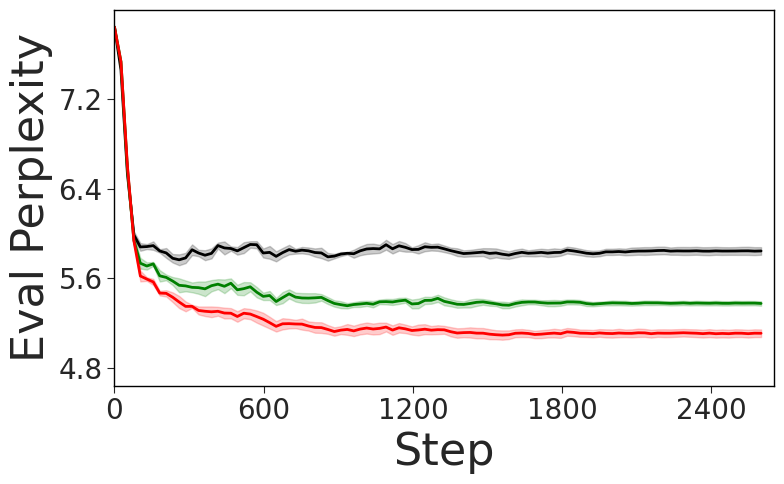

  [LoRA] + FullTraining: 5 seeds, final ppl=6.010
  [LoRA] + GlobalSubset: 5 seeds, final ppl=5.307
  [LoRA] + LayerWiseSubset: 5 seeds, final ppl=5.109
    -> ./figures/alpaca_samsum_LoRA.pdf


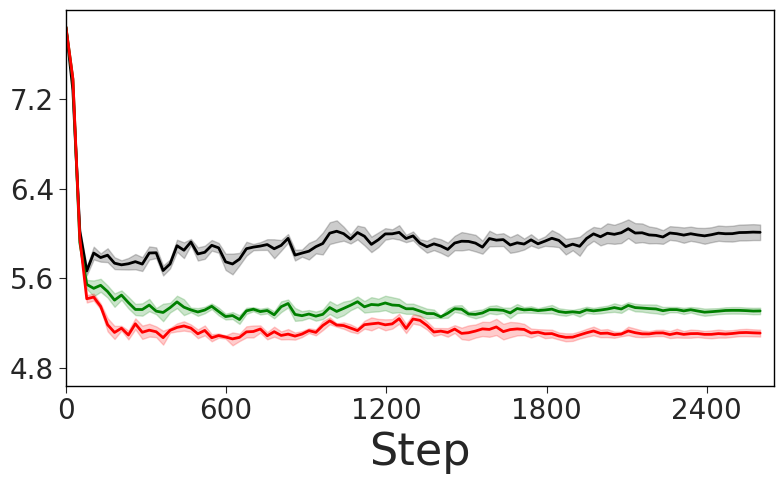

  [MeSO] + FullTraining: 5 seeds, final ppl=5.876
  [MeSO] + GlobalSubset: 5 seeds, final ppl=5.346
  [MeSO] + LayerWiseSubset: 5 seeds, final ppl=4.834
    -> ./figures/alpaca_samsum_MeSO.pdf


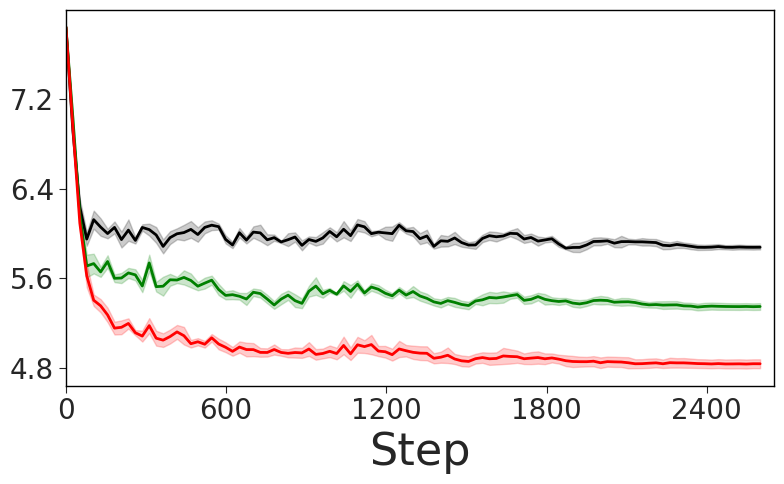


  less → tydiqa
  [LoRA] + FullTraining: 5 seeds, final ppl=5.961
  [LoRA] + GlobalSubset: 5 seeds, final ppl=3.337
  [LoRA] + LayerWiseSubset: 5 seeds, final ppl=1.918
    -> ./figures/less_tydiqa_LoRA.pdf


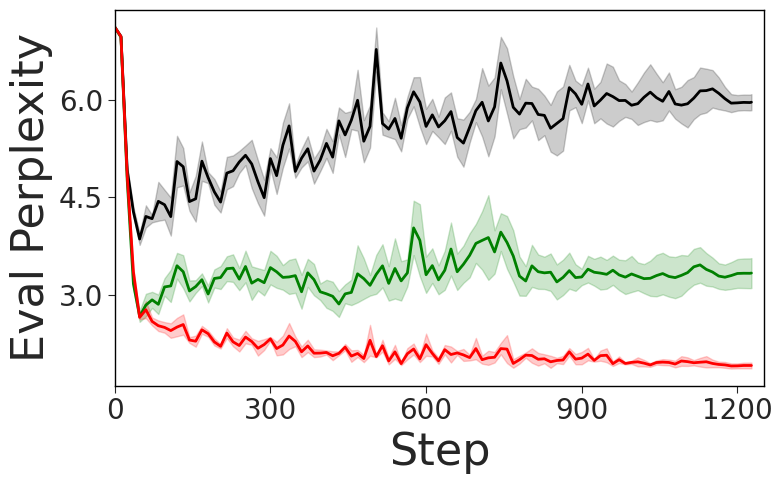


  triviaqa → nq_open
  [LoRA] + FullTraining: 5 seeds, final ppl=13.532
  [LoRA] + GlobalSubset: 5 seeds, final ppl=12.399
  [LoRA] + LayerWiseSubset: 5 seeds, final ppl=12.443
    -> ./figures/triviaqa_nq_LoRA.pdf


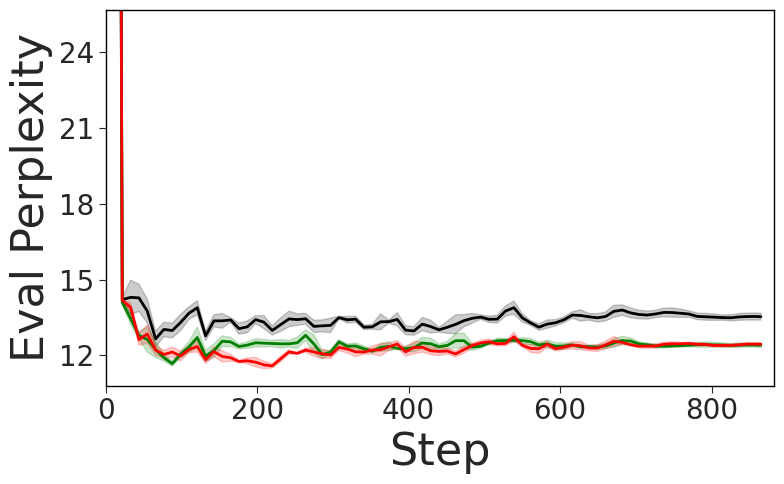


  less → squad
  [LoRA] + FullTraining: 5 seeds, final ppl=86.717
  [LoRA] + GlobalSubset: 5 seeds, final ppl=32.344
  [LoRA] + LayerWiseSubset: 5 seeds, final ppl=22.321
    -> ./figures/less_squad_LoRA.pdf


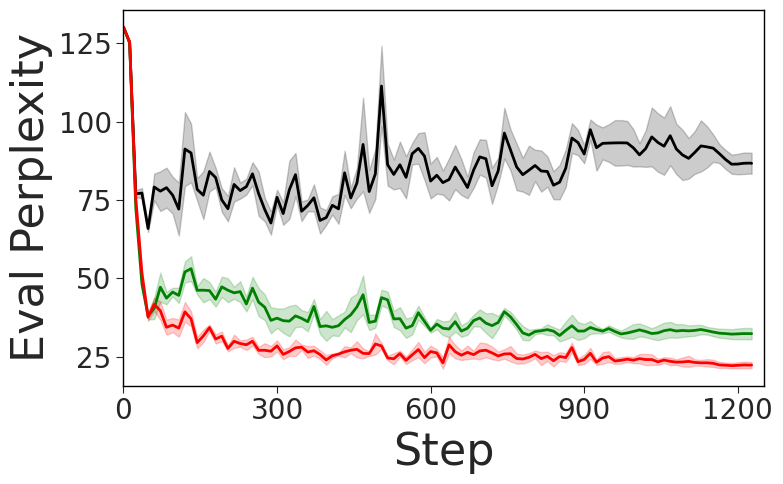


Saved legend: ./figures/legend.pdf


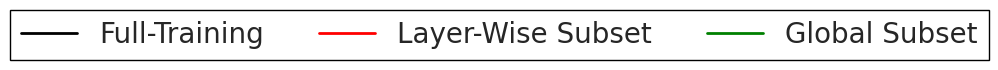

In [27]:
from matplotlib.ticker import MaxNLocator

# Per-(setting, ft) plots with shared y-limits within each setting.
# Target-only is excluded from these trajectory plots; only the 3 curation
# methods are drawn.
for ds in DATASETS:
    ds_key = ds['config']
    main_traj = all_main.get(ds_key, {})

    print(f"\n{'=' * 60}\n  {DATASET_TITLES.get(ds_key, ds_key)}\n{'=' * 60}")

    # First pass: collect axis ranges across all FTs in this setting (main only).
    x_max, y_min, y_max = None, None, None
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None:
                continue
            mean = d['eval_perplexity_mean']
            std  = d['eval_perplexity_std']
            if d['n_seeds'] > 1:
                lo, hi = (mean - std).min(), (mean + std).max()
            else:
                lo, hi = mean.min(), mean.max()
            x_max = d['steps'].max() if x_max is None else max(x_max, d['steps'].max())
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)

    if x_max is None:
        print('  no data'); continue
    # Optional per-setting cap (e.g. clip triviaqa_nq's ~174 step-0 ppl baseline).
    cap = ds.get('y_clip_max_ppl')
    if cap is not None:
        y_max = min(y_max, cap)
        y_min = min(y_min, cap)
    y_pad = (y_max - y_min) * 0.05

    # Second pass: render one figure per FT.
    for ft in ds['finetunings']:
        per_ft = main_traj.get(ft, {})
        if not per_ft:
            print(f"  [{ft}] no main data"); continue

        fig, ax = plt.subplots(figsize=(8, 5))
        fig.patch.set_facecolor('white'); ax.set_facecolor('white')

        for cur in CURATIONS:
            d = per_ft.get(cur)
            if d is None:
                continue
            color = METHOD_COLORS[cur]
            ax.plot(d['steps'], d['eval_perplexity_mean'], lw=2, color=color, label=LEGEND_NAMES[cur])
            if d['n_seeds'] > 1:
                ax.fill_between(d['steps'], d['eval_perplexity_mean'] - d['eval_perplexity_std'],
                                d['eval_perplexity_mean'] + d['eval_perplexity_std'],
                                color=color, alpha=0.2)
            print(f"  [{ft}] + {cur}: {d['n_seeds']} seeds, final ppl={d['eval_perplexity_mean'][-1]:.3f}")

        ax.set_xlabel('Step', fontsize=32)
        if ft == ds['finetunings'][0]:
            ax.set_ylabel('Eval Perplexity', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for sp in ax.spines.values(): sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_xlim(left=0, right=x_max * 1.02)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        plt.tight_layout()
        path = os.path.join(save_dir, f'{ds_key}_{ft}.pdf')
        fig.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> {path}")
        plt.show()

# Standalone legend (one canonical version for the 3 curation methods).
legend_specs = [
    ('Full-Training',     'black', '-'),
    ('Layer-Wise Subset', 'red',   '-'),
    ('Global Subset',     'green', '-'),
]
fig_leg, ax_leg = plt.subplots(figsize=(8, 0.5))
ax_leg.set_axis_off(); fig_leg.patch.set_facecolor('white')
handles = [plt.Line2D([0], [0], color=c, lw=2, linestyle=ls) for _, c, ls in legend_specs]
labels  = [n for n, _, _ in legend_specs]
legend = fig_leg.legend(handles, labels, loc='center', ncol=len(labels),
                        fontsize=20, frameon=True, edgecolor='black',
                        fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
path = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {path}")
plt.show()


## Paper Figures: Eval Loss vs Step (linear-scale companion)

Same data, but eval loss on a linear scale instead of perplexity on log scale. Useful when the perplexity tail dominates the visual range.


  -> ./figures/alpaca_samsum_Full_loss.pdf


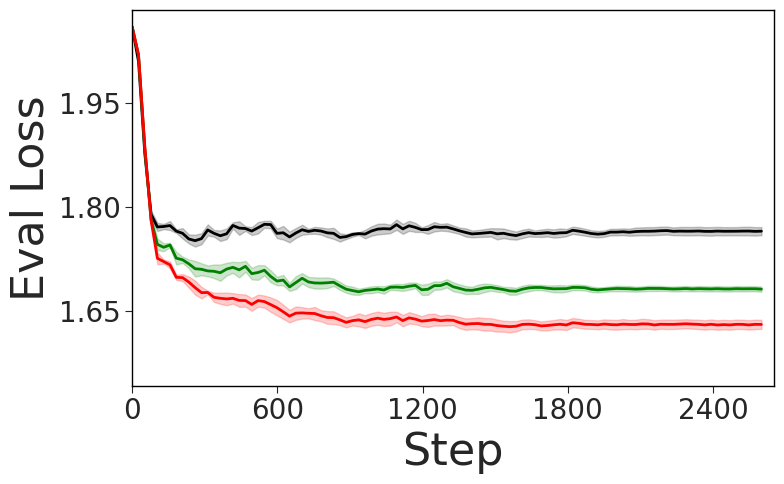

  -> ./figures/alpaca_samsum_LoRA_loss.pdf


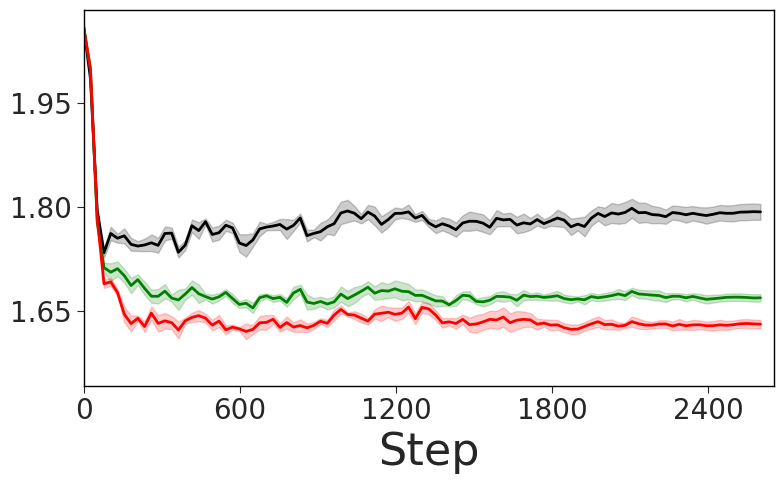

  -> ./figures/alpaca_samsum_MeSO_loss.pdf


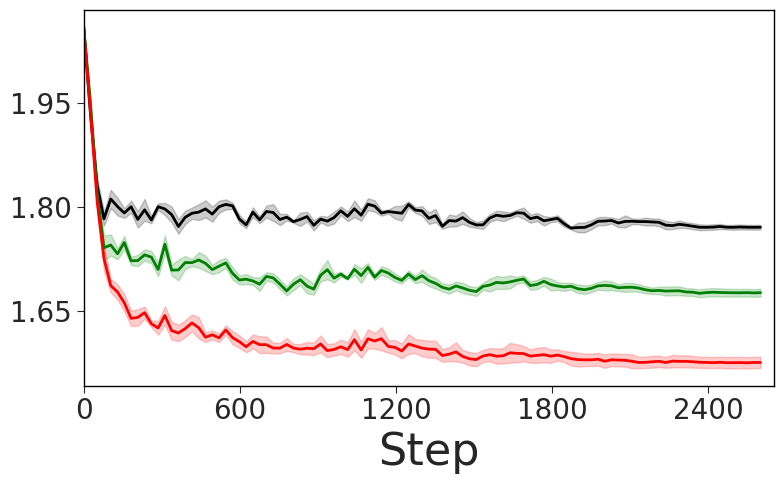

  -> ./figures/less_tydiqa_LoRA_loss.pdf


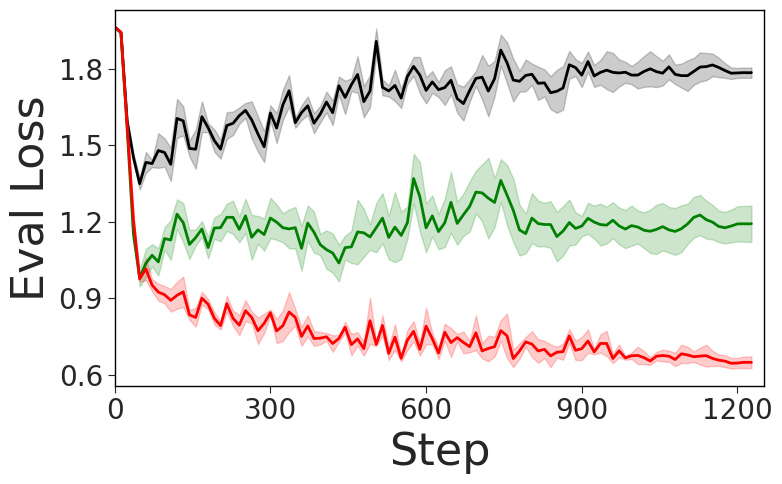

  -> ./figures/triviaqa_nq_LoRA_loss.pdf


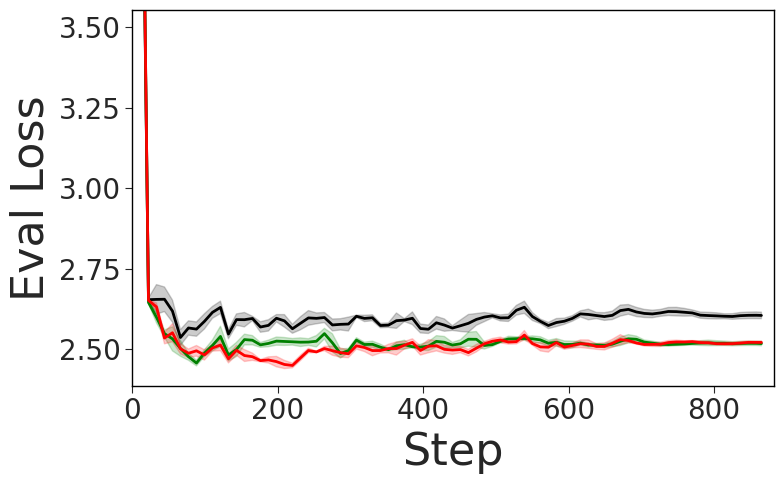

  -> ./figures/less_squad_LoRA_loss.pdf


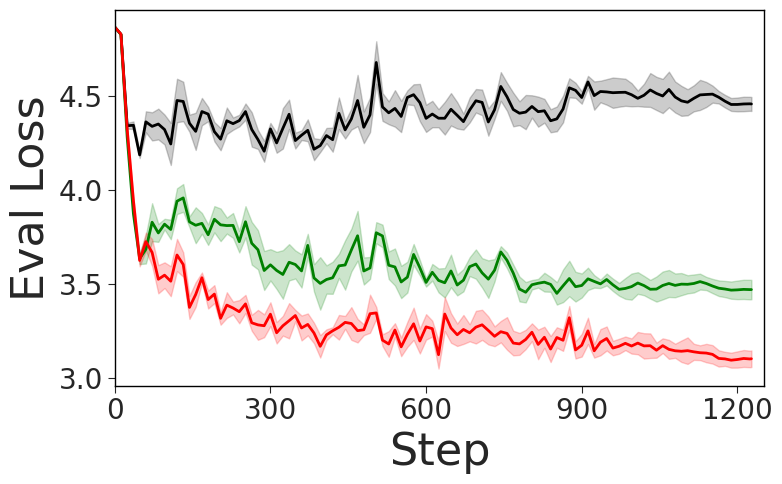

In [28]:
for ds in DATASETS:
    ds_key = ds['config']
    main_traj = all_main.get(ds_key, {})

    # Shared y-limits in eval_loss across this setting's FTs (main only).
    x_max = y_min = y_max = None
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None: continue
            mean, std = d['eval_loss_mean'], d['eval_loss_std']
            lo, hi = ((mean - std).min(), (mean + std).max()) if d['n_seeds'] > 1 else (mean.min(), mean.max())
            x_max = d['steps'].max() if x_max is None else max(x_max, d['steps'].max())
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)
    if x_max is None: continue
    cap = ds.get('y_clip_max_loss')
    if cap is not None:
        y_max = min(y_max, cap)
        y_min = min(y_min, cap)
    y_pad = (y_max - y_min) * 0.05

    for ft in ds['finetunings']:
        per_ft = main_traj.get(ft, {})
        if not per_ft: continue

        fig, ax = plt.subplots(figsize=(8, 5))
        fig.patch.set_facecolor('white'); ax.set_facecolor('white')

        for cur in CURATIONS:
            d = per_ft.get(cur)
            if d is None: continue
            color = METHOD_COLORS[cur]
            ax.plot(d['steps'], d['eval_loss_mean'], lw=2, color=color, label=LEGEND_NAMES[cur])
            if d['n_seeds'] > 1:
                ax.fill_between(d['steps'], d['eval_loss_mean'] - d['eval_loss_std'],
                                d['eval_loss_mean'] + d['eval_loss_std'],
                                color=color, alpha=0.2)

        ax.set_xlabel('Step', fontsize=32)
        if ft == ds['finetunings'][0]:
            ax.set_ylabel('Eval Loss', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for sp in ax.spines.values(): sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_xlim(left=0, right=x_max * 1.02)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        plt.tight_layout()
        path = os.path.join(save_dir, f'{ds_key}_{ft}_loss.pdf')
        fig.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"  -> {path}")
        plt.show()


## Results Tables: Task-Specific Metrics

Final-checkpoint downstream metric (mean ± SE over 5 seeds).


In [29]:
for ds in DATASETS:
    ds_key = ds['config']
    metric_traj = all_main_metric.get(ds_key, {})
    target_metric = all_target_metric.get(ds_key, {})

    spec = TASK_METRICS.get(ds['task'])
    if spec is None: continue
    primary = spec['primary']

    print(f"\n{DATASET_TITLES.get(ds_key, ds_key):<30} (primary: {primary})")
    print('=' * 70)
    print(f"  {'method':<26} {'mean ± SE':>16}  (n)")

    for ft in ds['finetunings']:
        rows = []
        for cur in CURATIONS:
            d = metric_traj.get(ft, {}).get(cur)
            if d and f'{primary}_mean' in d:
                rows.append((f'{cur}-{ft}',
                             d[f'{primary}_mean'], d[f'{primary}_se'], d[f'{primary}_n']))
        td = target_metric.get(ft)
        if td and f'{primary}_mean' in td:
            rows.append((f'Target-only-{ft}',
                         td[f'{primary}_mean'], td[f'{primary}_se'], td[f'{primary}_n']))
        if not rows: continue
        print(f"  -- {ft} --")
        for name, m, se, n in rows:
            print(f"  {name:<26} {m:>7.3f} ± {se:>6.3f}  (n={n})")



alpaca → samsum                (primary: rougeL)
  method                            mean ± SE  (n)
  -- Full --
  FullTraining-Full            0.150 ±  0.002  (n=5)
  GlobalSubset-Full            0.148 ±  0.005  (n=5)
  LayerWiseSubset-Full         0.144 ±  0.005  (n=5)
  Target-only-Full             0.289 ±  0.002  (n=5)
  -- LoRA --
  FullTraining-LoRA            0.182 ±  0.002  (n=5)
  GlobalSubset-LoRA            0.196 ±  0.005  (n=5)
  LayerWiseSubset-LoRA         0.222 ±  0.002  (n=5)
  Target-only-LoRA             0.299 ±  0.000  (n=5)
  -- MeSO --
  FullTraining-MeSO            0.093 ±  0.002  (n=5)
  GlobalSubset-MeSO            0.095 ±  0.004  (n=5)
  LayerWiseSubset-MeSO         0.097 ±  0.003  (n=5)
  Target-only-MeSO             0.285 ±  0.001  (n=5)

less → tydiqa                  (primary: f1_score)
  method                            mean ± SE  (n)
  -- LoRA --
  FullTraining-LoRA           10.128 ±  0.187  (n=5)
  GlobalSubset-LoRA           13.424 ±  1.035  (n=5)
  

## PPL Summary

Min / final / ratio across step trajectories (mean over 5 seeds). Ratio > 1 indicates overfitting (final ppl above the trajectory minimum).


In [30]:
for ds in DATASETS:
    ds_key = ds['config']
    main_traj   = all_main.get(ds_key, {})
    target_traj = all_target.get(ds_key, {})

    print(f"\n{DATASET_TITLES.get(ds_key, ds_key)}")
    print(f"{'finetuning':<8} {'method':<18} {'min_ppl':>9} {'fin_ppl':>10} {'ratio':>8}")
    print('-' * 60)
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None: continue
            m = d['eval_perplexity_mean']
            print(f"{ft:<8} {cur:<18} {m.min():>9.3f} {m[-1]:>10.3f} {m[-1] / m.min():>7.2f}x")
        td = target_traj.get(ft)
        if td is not None:
            m = td['eval_perplexity_mean']
            print(f"{ft:<8} {'Target-only':<18} {m.min():>9.3f} {m[-1]:>10.3f} {m[-1] / m.min():>7.2f}x")
        print()



alpaca → samsum
finetuning method               min_ppl    fin_ppl    ratio
------------------------------------------------------------
Full     FullTraining           5.764      5.843    1.01x
Full     GlobalSubset           5.353      5.373    1.00x
Full     LayerWiseSubset        5.091      5.107    1.00x
Full     Target-only            6.002     57.534    9.59x

LoRA     FullTraining           5.664      6.010    1.06x
LoRA     GlobalSubset           5.230      5.307    1.01x
LoRA     LayerWiseSubset        5.057      5.109    1.01x
LoRA     Target-only            5.755    352.678   61.28x

MeSO     FullTraining           5.868      5.876    1.00x
MeSO     GlobalSubset           5.342      5.346    1.00x
MeSO     LayerWiseSubset        4.832      4.834    1.00x
MeSO     Target-only            6.001     57.622    9.60x


less → tydiqa
finetuning method               min_ppl    fin_ppl    ratio
------------------------------------------------------------
LoRA     FullTraining      